In [1]:
%pip install --quiet python-dotenv pydantic-ai 'natural-pdf[ai]'

import os
from pathlib import Path
import nest_asyncio; nest_asyncio.apply()

# Download data files if not already present (e.g. on Colab)
if not Path("data").exists():
    import zipfile, urllib.request
    url = "https://github.com/jsoma/workshop-ai-images-video/raw/main/docs/nicar-2026/02-documents-data.zip"
    print("Downloading data...")
    urllib.request.urlretrieve(url, "_data.zip")
    with zipfile.ZipFile("_data.zip") as zf:
        zf.extractall("data")
    Path("_data.zip").unlink()
    print("Done!")

# Load API keys: Colab secrets or local .env
try:
    from google.colab import userdata
    os.environ.setdefault("GOOGLE_API_KEY", userdata.get("GOOGLE_API_KEY"))
except ImportError:
    from dotenv import load_dotenv
    load_dotenv()

DATA = Path("data")
Path("outputs").mkdir(exist_ok=True)


Note: you may need to restart the kernel to use updated packages.


# Documents

PDFs are images too. Text trapped in a scan, a photo of a posted notice, a 500-page FOIA dump — these are all "images with text in them."

## OCR with an LLM

Send a photo (of a document or otherwise) to an LLM. Get structured text back.


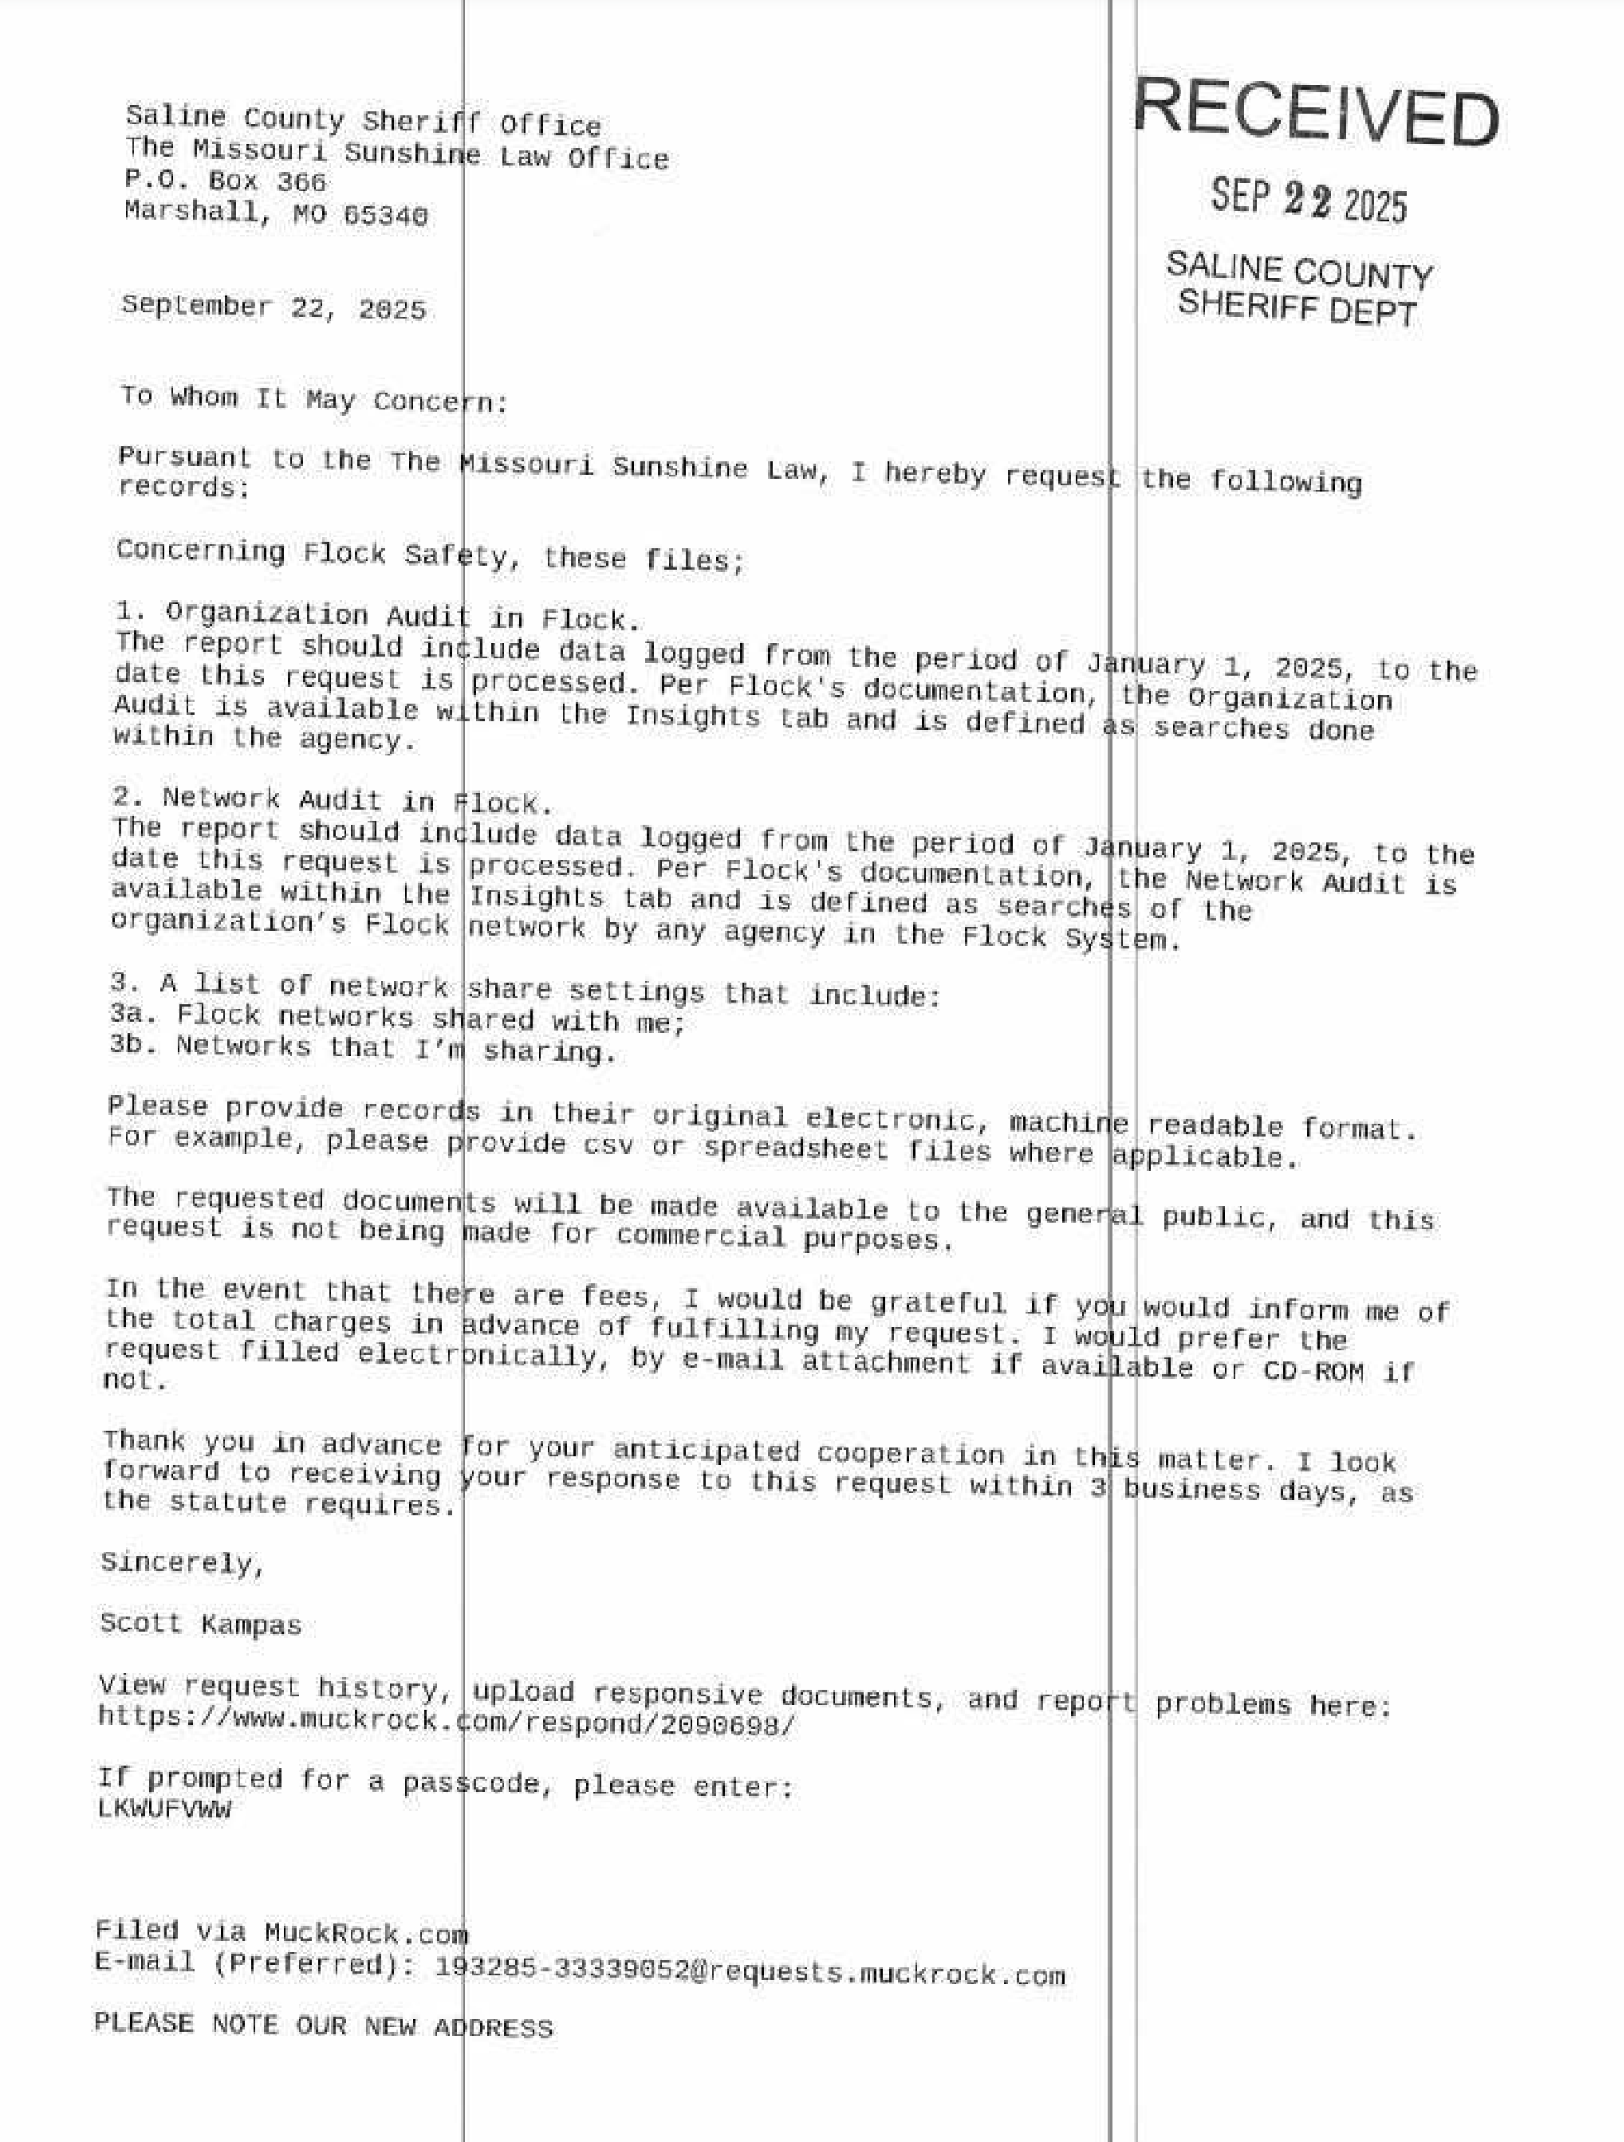

In [2]:
from IPython.display import Image
Image(filename="data/flock-scan.png", width=500)


**`documents/llm-ocr.py`** — Send an image to an LLM and get the text back


In [3]:
from pathlib import Path

from pydantic_ai import Agent, BinaryContent

DATA = Path("data")
MODEL = "openai:gpt-5-nano"
IMAGE = DATA / "flock-scan.png"

agent = Agent(MODEL)

result = agent.run_sync([
    "Extract all visible text from this image. Preserve layout and reading order.",
    BinaryContent(data=IMAGE.read_bytes(), media_type="image/png"),
])

print(result.output)


Saline County Sheriff office
The Missouri Sunshine Law Office
P.O. Box 366
Marshall, MO 65340

September 22, 2025

To Whom It May Concern:

Pursuant to the The Missouri Sunshine Law, I hereby request the following records:

Concerning Flock Safety, these files;

1. Organization Audit in Flock.
The report should include data logged from the period of January 1, 2025, to the date this request is processed. Per Flock's documentation, the Organization Audit is available within the Insights tab and is defined as searches done within the agency's Flock System.

2. Network Audit in Flock.
The report should include data logged from the period of January 1, 2025, to the date this request is processed. Per Flock's documentation, the Network Audit is available within the Insights tab and is defined as searches of the network by any agency in the Flock System.

3. A list of network share settings that include:
3a. Flock networks shared with me;
3b. Networks that I'm sharing.

Please provide record

## Extract structured data from PDFs

The workflow that goes from PDF->LLM->structured data is a little more difficult than it should be, so I made a library called [Natural PDF](https://github.com/jsoma/natural-pdf) to help you do that.

In this example, we pull specific fields from a document page. Visual citations show exactly where on the page each answer came from — you can see what the model looked at.


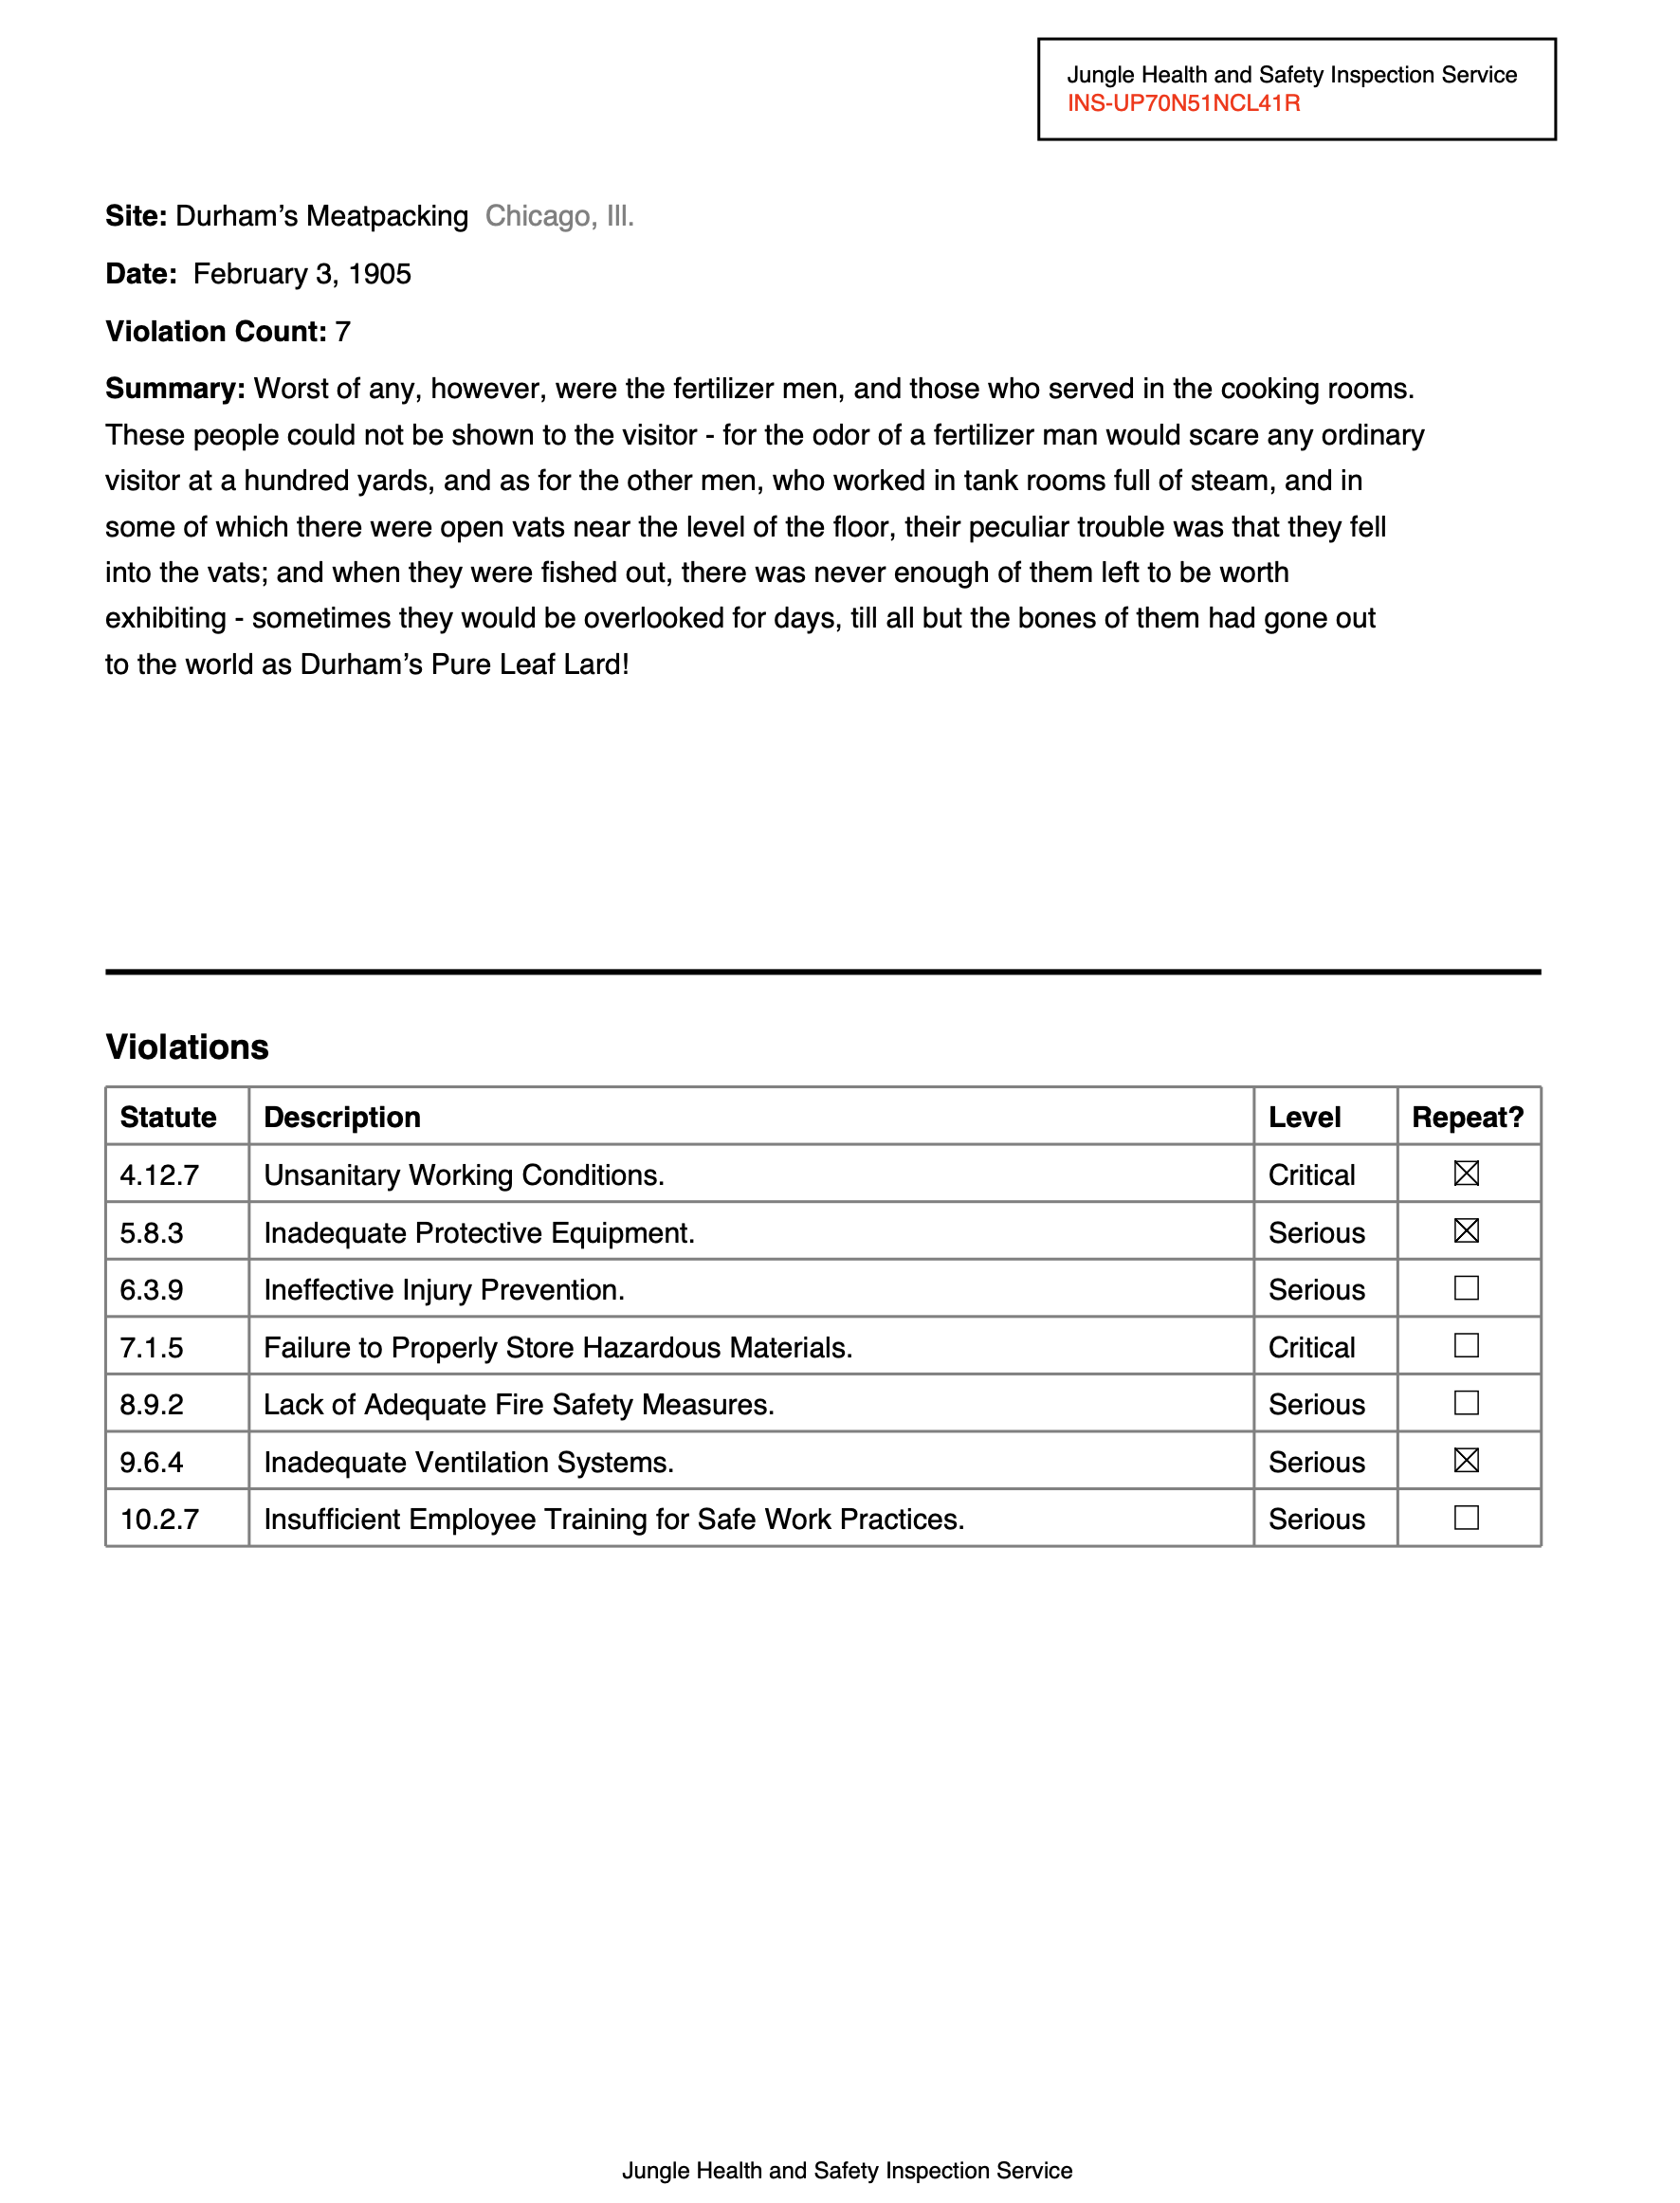

In [4]:
from IPython.display import Image
Image(filename="data/natural-pdf.png", width=500)


**`documents/extract-pdf.py`** — Extract structured data from a PDF page with an LLM, with visual citations


In [5]:
from pathlib import Path

import os
from openai import OpenAI
from natural_pdf import PDF

URL = "https://github.com/jsoma/natural-pdf/raw/refs/heads/main/pdfs/01-practice.pdf"

client = OpenAI(
    api_key=os.environ["GOOGLE_API_KEY"],
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
)

pdf = PDF(URL)
page = pdf.pages[0]

fields = ["site", "date", "violation count", "inspection service", "summary", "city", "state"]
results = page.extract(fields, client=client, model="gemini-2.5-flash")
print(results.to_dict())

results.show()


{'site': 'Durham\nM\n\n\nMeatpacking', 'date': 'February 3, 1905', 'violation_count': '7', 'inspection_service': 'Jungle Health and Safety Inspection Service', 'summary': 'Worst of any, however, were the fertilizer men, and those who served in the cooking rooms. These people could not be shown to the visitor - for the odor of a fertilizer man would scare any ordinary visitor at a hundred yards, and as for the other men, who worked in tank rooms full of steam, and in some of which there were open vats near the level of the floor, their peculiar trouble was that they fell into the vats; and when they were fished out, there was never enough of them left to be worth exhibiting - sometimes they would be overlooked for days, till all but the bones of them had gone out to the world as Durham\n\n\nPure Leaf Lard!', 'city': 'Chicago', 'state': 'Ill.'}


## Extract with a Pydantic schema

Same extraction, but with a Pydantic schema for precise field control. Same pattern as the image demos — define your fields, the model fills them in.


**`documents/extract-pdf-pydantic.py`** — Extract structured data from a PDF using a Pydantic schema


In [6]:
from pathlib import Path

import os
from openai import OpenAI
from pydantic import BaseModel, Field
from natural_pdf import PDF

URL = "https://github.com/jsoma/natural-pdf/raw/refs/heads/main/pdfs/01-practice.pdf"

client = OpenAI(
    api_key=os.environ["GOOGLE_API_KEY"],
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
)

class ReportInfo(BaseModel):
    inspection_number: str = Field(description="The main report identifier")
    inspection_date: str = Field(description="Date of the inspection")
    inspection_service: str = Field(description="Name of inspection service")
    site: str = Field(description="Name of company inspected")
    summary: str = Field(description="Visit summary")
    city: str
    state: str = Field(description="Full name of state")
    violation_count: int

pdf = PDF(URL)
page = pdf.pages[0]
page.extract(schema=ReportInfo, client=client, model="gemini-2.5-flash")

print(dict(page.extracted()))


{'inspection_number': FieldResult(value='INS-UP70N51NCL41R', citations=0 elements), 'inspection_date': FieldResult(value='February 3, 1905', citations=0 elements), 'inspection_service': FieldResult(value='Jungle Health and Safety Inspection Service', citations=0 elements), 'site': FieldResult(value='Durham’s Meatpacking', citations=0 elements), 'summary': FieldResult(value='Worst of any, however, were the fertilizer men, and those who served in the cooking rooms. These people could not be shown to the visitor - for the odor of a fertilizer man would scare any ordinary visitor at a hundred yards, and as for the other men, who worked in tank rooms full of steam, and in some of which there were open vats near the level of the floor, their peculiar trouble was that they fell into the vats; and when they were fished out, there was never enough of them left to be worth exhibiting - sometimes they would be overlooked for days, till all but the bones of them had gone out to the world as Durham

## Classify pages visually

If you're trying to put content in rough categories, there are models that can do it for free! While they aren't perfect about nuance, if you're trying to split up invoices and photographs and love letters they can do a pretty good job. *And they run on your own computer*

Got hundreds of pages from a FOIA? Classify every page as diagram, text, invoice, blank — no API key needed. Then filter to just the ones you want.


**`documents/classify-pages.py`** — Classify pages of a PDF visually (diagram, text, invoice, etc.) using CLIP


Could not get FontBBox from font descriptor because None cannot be parsed as 4 floats


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Device set to use mps:0


Classifying batch (openai/clip-vit-base-patch16):   0%|          | 0/17 [00:00<?, ?it/s]

Page 1: invoice (0.51)
Page 2: text (0.97)
Page 3: text (0.95)
Page 4: diagram (0.90)
Page 5: diagram (0.91)
Page 6: invoice (0.97)
Page 7: text (0.89)
Page 8: invoice (0.79)
Page 9: invoice (0.97)
Page 10: invoice (0.98)
Page 11: invoice (0.99)
Page 12: invoice (0.99)
Page 13: text (0.88)
Page 14: text (0.93)
Page 15: diagram (0.93)
Page 16: text (0.82)
Page 17: invoice (0.95)

Found 3 diagram pages


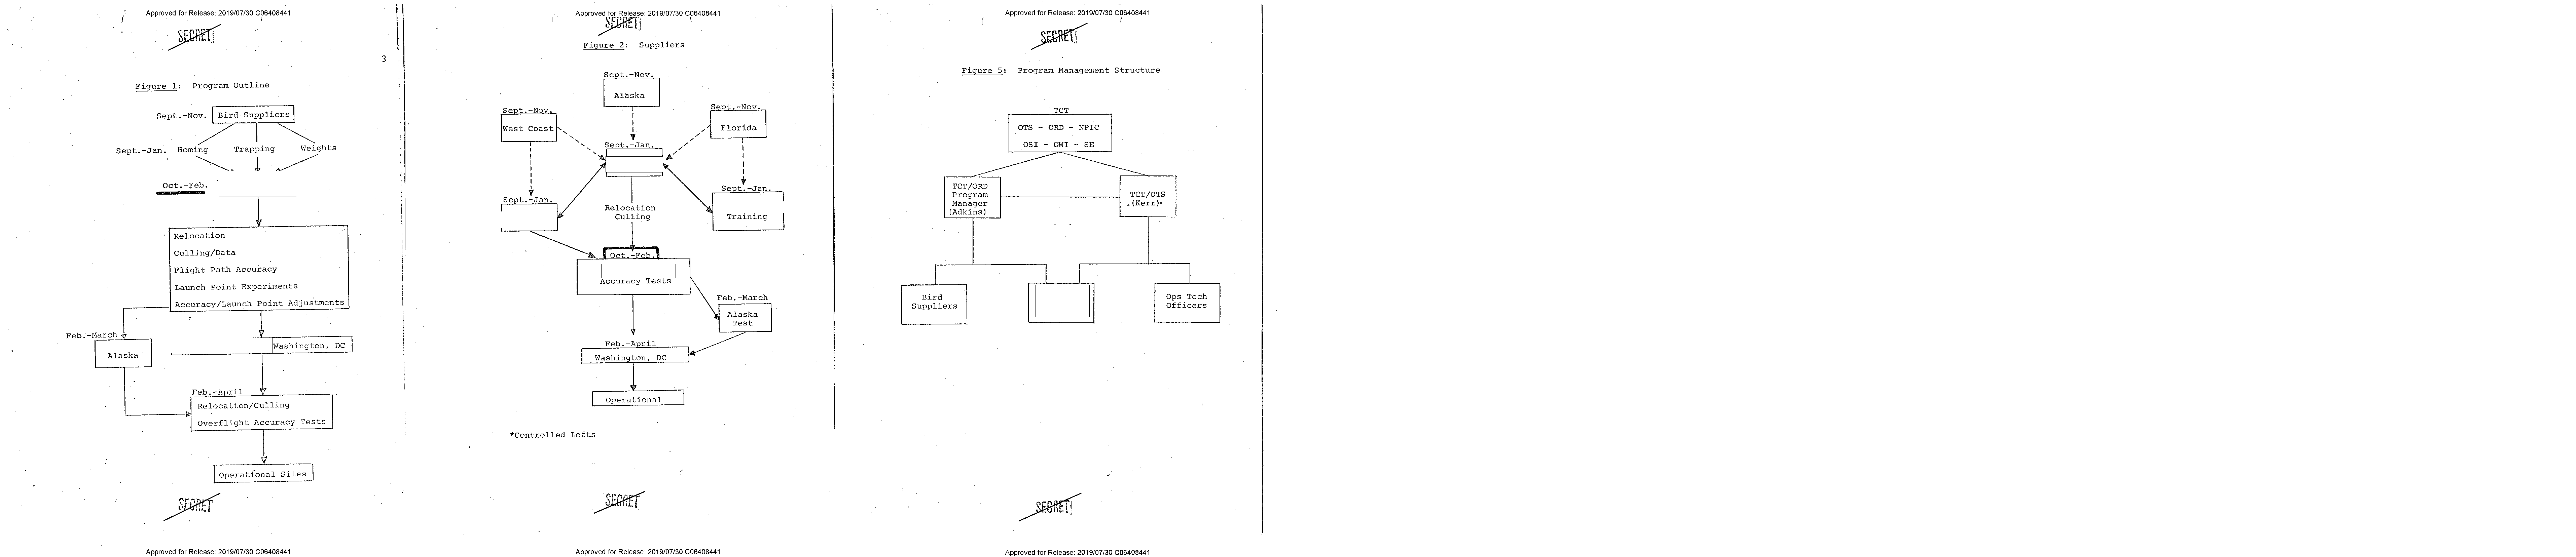

In [7]:
from natural_pdf import PDF

URL = "https://github.com/jsoma/ire25-natural-pdf/raw/refs/heads/main/cia-doc.pdf"

pdf = PDF(URL)
pdf.classify_pages(['diagram', 'text', 'invoice', 'blank'], using='vision')

for page in pdf.pages:
    print(f"Page {page.number}: {page.category} ({page.category_confidence:.2f})")

diagrams = pdf.pages.filter(lambda p: p.category == 'diagram')
print(f"\nFound {len(diagrams)} diagram pages")
diagrams.show(show_category=True)
